In [1]:
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0, 10, 100)

# inlet concentration
c_t = np.zeros_like(t)
c_t[70:] = 1
c_t[30:70] = np.linspace(0, 1, 40)

In [2]:
gauss = (
    lambda x, mu, sigma: 1
    / np.sqrt(2 * np.pi * sigma**2)
    * np.exp(-1 / 2 * ((x - mu) / sigma) ** 2)
)
E_t = gauss(t, 3.0, 0.5)

In [3]:
# calculate the new time scale
t_c = np.linspace(2 * t[0], 2 * t[-1], 199)

In [4]:
# convolve E with c
c_out = np.convolve(E_t, c_t, mode="full")

In [5]:
print(c_out.shape)

(199,)


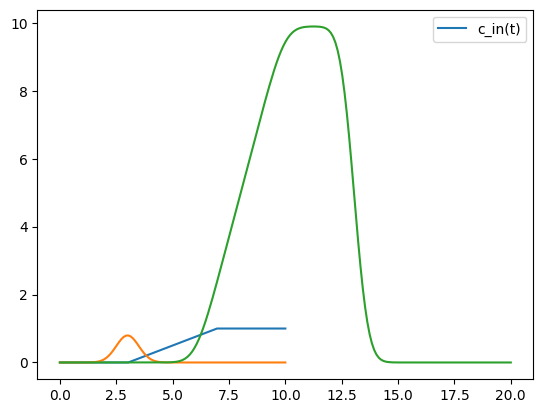

In [6]:
# plotting
plt.plot(t, c_t, label="c_in(t)")
plt.plot(t, E_t)
plt.plot(t_c, c_out)
plt.legend()
plt.show()

In [7]:
n_disc = 100
n_kernel = 100

t_disc = np.linspace(0, 10, n_disc)
t_kernel = np.linspace(0, 10, n_kernel)

t_c = np.linspace(
    t_disc[0] + t_kernel[0], t_disc[-1] + t_kernel[-1], n_disc + n_kernel - 1
)

In [8]:
c_0 = np.zeros_like(t_disc)
c_0[t_disc > 2.5] = 1

E = np.ones(n_kernel)
E[2.5 > t_kernel] = 0
E[5 < t_kernel] = 0

c = np.convolve(c_0, E, mode="full")

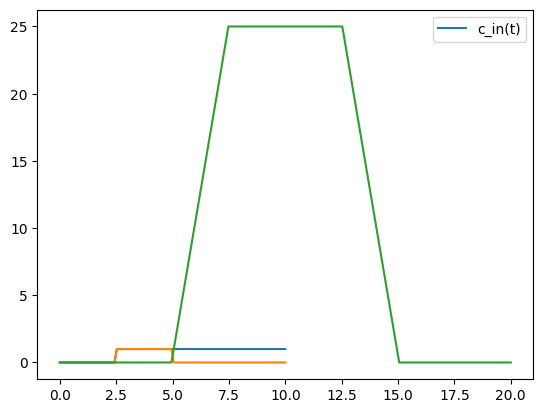

In [9]:
plt.plot(t_disc, c_0, label="c_in(t)")
plt.plot(t_kernel, E)
plt.plot(t_c, c)
plt.legend()
plt.show()